# Ecommerce Purchase Prediction
## PySpark + LightGBM Pipeline

Viết lại toàn bộ pipeline từ `process_data_v2.ipynb` bằng:
- **PySpark** – xử lý dữ liệu lớn (42M+ dòng) phân tán
- **LightGBM** – mô hình gradient boosting nhanh, hiệu quả

**Mục tiêu:** Dự đoán `is_purchased` (1/0) – liệu user có mua sản phẩm sau khi view hay không.

**Schema dữ liệu gốc:**

| Cột | Kiểu | Mô tả |
|-----|------|-------|
| `event_time` | str | Thời gian sự kiện |
| `event_type` | str | `view` / `cart` / `purchase` |
| `product_id` | int64 | ID sản phẩm |
| `category_id` | int64 | ID danh mục |
| `category_code`| str | Mã danh mục phân cấp |
| `brand` | str | Thương hiệu |
| `price` | float32 | Giá sản phẩm |
| `user_id` | int64 | ID người dùng |
| `user_session` | str | ID phiên |

---
**Cài đặt thư viện:**
```bash
pip install pyspark lightgbm scikit-learn matplotlib
```

## Imports

In [1]:
import os
import time

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

# LightGBM
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn import metrics
import numpy as np
import pandas as pd

# Matplotlib — inline cho Jupyter
import matplotlib.pyplot as plt
%matplotlib inline

print("✅ Imports xong.")

✅ Imports xong.


## Cấu hình đường dẫn

> ⚠️ **Chỉnh `CSV_PATH`** cho phù hợp với môi trường của bạn.

In [4]:
# !! Chỉnh đường dẫn này !!
CSV_PATH = "/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv"
PQ_PATH  = CSV_PATH.replace(".csv", "_zstd.parquet")

# Thư mục xuất kết quả (model, biểu đồ)
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NOTEBOOK_DIR = os.path.abspath(os.getcwd())

PROJECT_ROOT = (
    os.path.dirname(NOTEBOOK_DIR)
    if os.path.basename(NOTEBOOK_DIR) == "models"
    else NOTEBOOK_DIR
)

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "models", "lgbm_output")
MODEL_PATH = os.path.join(OUTPUT_DIR, "lgbm_model.txt")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"CSV_PATH   : {CSV_PATH}")
print(f"PQ_PATH    : {PQ_PATH}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")

CSV_PATH   : /kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv
PQ_PATH    : /kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov_zstd.parquet
OUTPUT_DIR : /kaggle/working/models/lgbm_output


## Khởi tạo Spark Session

In [5]:
spark = (
    SparkSession.builder
    .appName("EcommerceAnalysis_LightGBM")
    .config("spark.driver.memory", "8g")          # Tăng nếu máy có RAM lớn
    .config("spark.executor.memory", "8g")
    .config("spark.sql.shuffle.partitions", "200") # Tối ưu shuffle
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("✅ SparkSession sẵn sàng.")
print(f"   Spark version : {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/28 13:28:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ SparkSession sẵn sàng.
   Spark version : 4.0.2


## Load & Clean Data

In [6]:
t0 = time.time()

if os.path.exists(PQ_PATH):
    print(f"→ Đọc từ Parquet: {PQ_PATH}")
    df_raw = spark.read.parquet(PQ_PATH)
else:
    print(f"→ Đọc từ CSV    : {CSV_PATH}")
    df_raw = (
        spark.read
        .option("header", "true")
        .option("inferSchema", "true")
        .csv(CSV_PATH)
    )

# Lọc bỏ null ở các cột quan trọng
df = (
    df_raw
    .filter(
        F.col("user_session").isNotNull() &
        F.col("user_id").isNotNull() &
        F.col("product_id").isNotNull()
    )
    .fillna("unknown", subset=["brand", "category_code"])
)

# Parse event_date từ event_time ("2019-10-01 00:00:00 UTC")
df = df.withColumn(
    "event_date",
    F.to_date(F.substring(F.col("event_time"), 1, 10), "yyyy-MM-dd")
)

total_rows = df.count()
print(f"\nTổng số hàng sau lọc : {total_rows:,}")
print(f"Thời gian đọc        : {time.time() - t0:.2f}s")

→ Đọc từ CSV    : /kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv



Tổng số hàng sau lọc : 67,501,969
Thời gian đọc        : 154.68s


In [7]:
df.printSchema()

root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = false)
 |-- brand: string (nullable = false)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)
 |-- event_date: date (nullable = true)



In [8]:
# Xem 5 dòng đầu
df.limit(5).toPandas()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date
0,2019-11-01 00:00:00,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33,2019-11-01
1,2019-11-01 00:00:00,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283,2019-11-01
2,2019-11-01 00:00:01,view,17302664,2053013553853497655,unknown,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387,2019-11-01
3,2019-11-01 00:00:01,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f,2019-11-01
4,2019-11-01 00:00:01,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2,2019-11-01


## Visitors Daily Trend

In [9]:
visitor_by_date = (
    df.select("event_date", "user_id")
    .dropDuplicates()
    .groupBy("event_date")
    .agg(F.count("user_id").alias("unique_visitors"))
    .orderBy("event_date")
)

vbd_pd = visitor_by_date.toPandas()
vbd_pd.head()

,event_date,unique_visitors
0,2019-11-01,223108
1,2019-11-02,234685
2,2019-11-03,240187
3,2019-11-04,275612
4,2019-11-05,262338


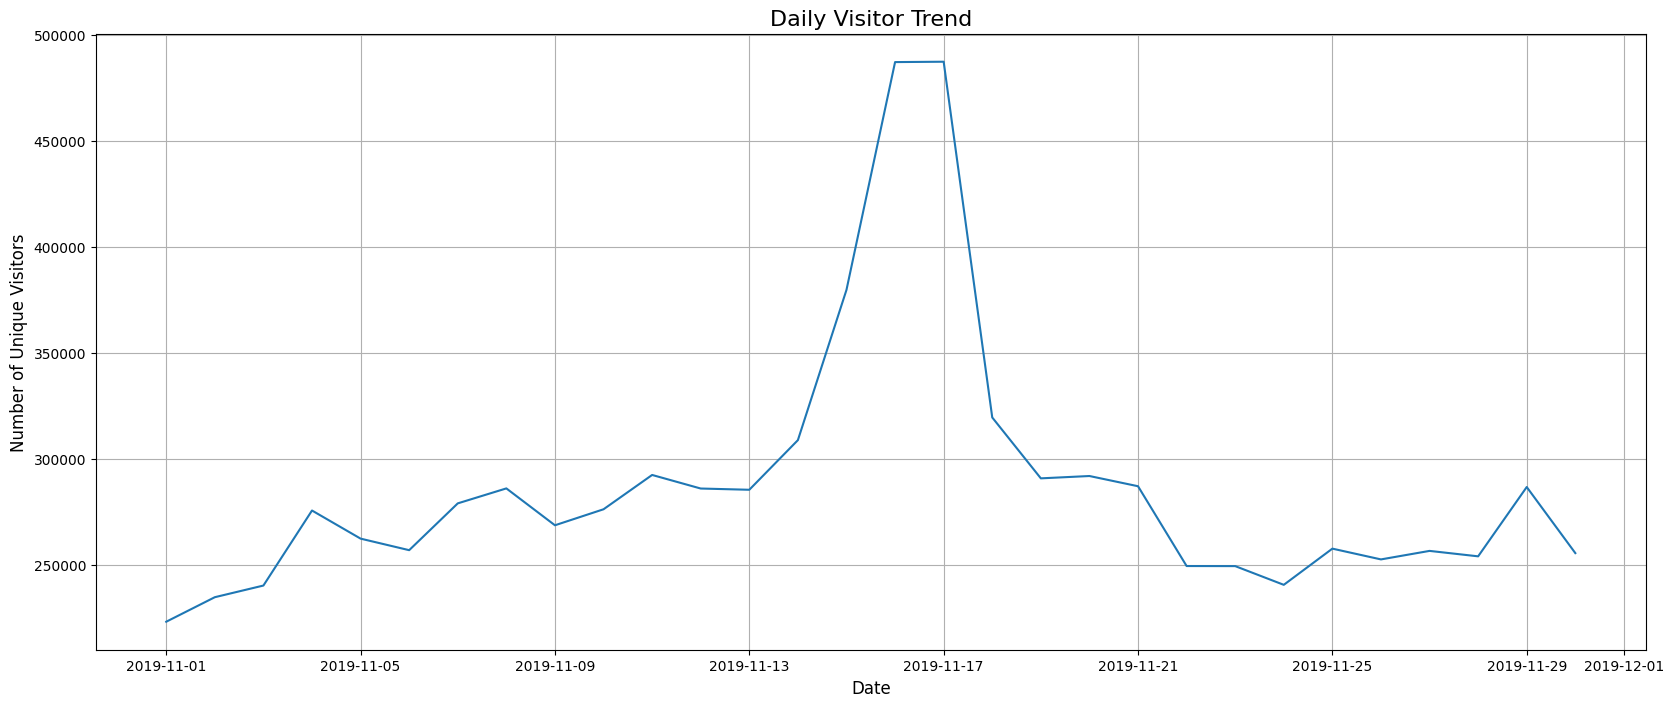

In [10]:
plt.rcParams["figure.figsize"] = (20, 8)
plt.plot(vbd_pd["event_date"], vbd_pd["unique_visitors"])
plt.title("Daily Visitor Trend", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Unique Visitors", fontsize=12)
plt.grid(True)
plt.show()

## Feature Engineering

### Tách `category_code` thành 2 cấp

```
"electronics.smartphone"  →  level1 = "electronics",  level2 = "smartphone"
"appliances.kitchen.hood" →  level1 = "appliances",   level2 = "kitchen"
```

In [11]:
df = df.withColumn(
    "category_code_level1",
    F.when(
        F.col("category_code") != "unknown",
        F.split(F.col("category_code"), "\\.").getItem(0)
    ).otherwise("unknown")
).withColumn(
    "category_code_level2",
    F.when(
        F.col("category_code") != "unknown",
        F.split(F.col("category_code"), "\\.").getItem(1)
    ).otherwise("unknown")
).withColumn(
    "event_weekday",
    F.dayofweek(F.col("event_date")).cast(IntegerType())  # 1=Sun … 7=Sat
)

# Nhãn gốc mức event
df = df.withColumn(
    "is_purchased",
    F.when(F.col("event_type") == "purchase", 1).otherwise(0)
)

print("✅ Feature engineering xong.")
df.select("category_code", "category_code_level1", "category_code_level2",
          "event_weekday").limit(5).toPandas()

✅ Feature engineering xong.


,category_code,category_code_level1,category_code_level2,event_weekday
0,electronics.smartphone,electronics,smartphone,6
1,appliances.sewing_machine,appliances,sewing_machine,6
2,unknown,unknown,unknown,6
3,appliances.kitchen.washer,appliances,kitchen,6
4,electronics.smartphone,electronics,smartphone,6


## Aggregations (Spark GroupBy)

Tính 4 nhóm feature tổng hợp:
1. **User-level** – tổng sessions, số ngày hoạt động
2. **Product-level** – viewers, purchases, tỉ lệ mua sau cart, giá trung bình
3. **Session-level** – số view, số sản phẩm unique trong session
4. **User × Product** – số lần user view sản phẩm đó, có từng mua chưa

In [12]:
# 6a. User-level features
user_feats = (
    df.groupBy("user_id")
    .agg(
        F.countDistinct("user_session").alias("user_total_sessions"),
        F.countDistinct("event_date").alias("user_active_days"),
    )
)

# 6b. Product-level features
product_feats = (
    df.groupBy("product_id")
    .agg(
        F.countDistinct("user_id").alias("product_unique_viewers"),
        F.sum(F.when(F.col("event_type") == "purchase", 1).otherwise(0))
         .alias("product_total_purchases"),
        F.sum(F.when(F.col("event_type") == "cart", 1).otherwise(0))
         .alias("product_total_carts"),
        F.mean("price").alias("product_avg_price"),
        F.stddev("price").alias("product_price_std"),
    )
    .withColumn(
        "product_cart_to_purchase_rate",
        F.when(
            F.col("product_total_carts") > 0,
            F.col("product_total_purchases") / F.col("product_total_carts")
        ).otherwise(0.0)
    )
)

# 6c. Session-level features
session_feats = (
    df.groupBy("user_session")
    .agg(
        F.sum(F.when(F.col("event_type") == "view", 1).otherwise(0))
         .alias("session_view_count"),
        F.countDistinct("product_id").alias("session_unique_products"),
    )
)

# 6d. User × Product interaction
user_product_feats = (
    df.groupBy("user_id", "product_id")
    .agg(
        F.sum(F.when(F.col("event_type") == "view", 1).otherwise(0))
         .alias("user_product_view_count"),
        F.max(F.when(F.col("event_type") == "purchase", 1).otherwise(0))
         .alias("user_ever_purchased_product"),
    )
)

print("✅ Aggregation DataFrames đã định nghĩa (lazy).")

✅ Aggregation DataFrames đã định nghĩa (lazy).


## Join Features → df_rich

In [13]:
# Chỉ lấy hàng "view" làm tập mẫu;
# nhãn: user có mua sản phẩm đó (bất kỳ lúc nào) không?
df_view = df.filter(F.col("event_type") == "view")

df_rich = (
    df_view
    .join(user_feats,         on="user_id",                  how="left")
    .join(product_feats,      on="product_id",               how="left")
    .join(session_feats,      on="user_session",             how="left")
    .join(user_product_feats, on=["user_id", "product_id"],  how="left")
    .withColumn(
        "price_vs_product_avg",
        F.when(
            F.col("product_avg_price").isNotNull() & (F.col("product_avg_price") > 0),
            F.col("price") / F.col("product_avg_price")
        ).otherwise(1.0)
    )
    .withColumn("activity_count", F.col("session_view_count"))
    .withColumn(
        "is_purchased",
        F.when(F.col("user_ever_purchased_product") == 1, 1).otherwise(0)
    )
)

print("✅ df_rich đã dựng xong.")
df_rich.printSchema()

✅ df_rich đã dựng xong.
root
 |-- user_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- user_session: string (nullable = true)
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = false)
 |-- brand: string (nullable = false)
 |-- price: double (nullable = true)
 |-- event_date: date (nullable = true)
 |-- category_code_level1: string (nullable = true)
 |-- category_code_level2: string (nullable = true)
 |-- event_weekday: integer (nullable = true)
 |-- is_purchased: integer (nullable = false)
 |-- user_total_sessions: long (nullable = true)
 |-- user_active_days: long (nullable = true)
 |-- product_unique_viewers: long (nullable = true)
 |-- product_total_purchases: long (nullable = true)
 |-- product_total_carts: long (nullable = true)
 |-- product_avg_price: double (nullable = true)
 |-- product_price_std: double (nullable = true)
 |-- product

In [ ]:
df_rich.limit(5).toPandas()

## Prepare ML Features

- Encode categorical bằng `StringIndexer` (Spark ML)
- Convert sang Pandas để train LightGBM

In [14]:
CAT_COLS = ["brand", "category_code_level1", "category_code_level2", "event_weekday"]
NUM_COLS = [
    "user_total_sessions",
    "user_active_days",
    "product_cart_to_purchase_rate",
    "product_total_purchases",
    "product_unique_viewers",
    "activity_count",
    "session_view_count",
    "session_unique_products",
    "price",
    "price_vs_product_avg",
    "user_product_view_count",
]
LABEL_COL = "is_purchased"

# StringIndexer encode cho từng cột categorical
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in CAT_COLS
]
pipeline       = Pipeline(stages=indexers)
pipeline_model = pipeline.fit(df_rich)
df_encoded     = pipeline_model.transform(df_rich)

CAT_IDX_COLS    = [f"{c}_idx" for c in CAT_COLS]
ALL_FEATURE_COLS = CAT_IDX_COLS + NUM_COLS

print("Feature columns:", ALL_FEATURE_COLS)

Feature columns: ['brand_idx', 'category_code_level1_idx', 'category_code_level2_idx', 'event_weekday_idx', 'user_total_sessions', 'user_active_days', 'product_cart_to_purchase_rate', 'product_total_purchases', 'product_unique_viewers', 'activity_count', 'session_view_count', 'session_unique_products', 'price', 'price_vs_product_avg', 'user_product_view_count']


In [16]:
select_cols = ALL_FEATURE_COLS + [LABEL_COL]
N_TARGET = 150_000  # 150K mỗi class → tổng ~300K

df_clean = df_encoded.select(*select_cols).dropna().cache()

# Đếm từng class
n_pos = df_clean.filter(F.col(LABEL_COL) == 1).count()
n_neg = df_clean.filter(F.col(LABEL_COL) == 0).count()
print(f"   Class 1 (purchase) : {n_pos:,}")
print(f"   Class 0 (no-buy)   : {n_neg:,}")

# Tính fraction để lấy đúng N_TARGET mỗi class
frac_pos = min(N_TARGET / max(n_pos, 1), 1.0)
frac_neg = min(N_TARGET / max(n_neg, 1), 1.0)

# Sample cân bằng trong Spark → chỉ toPandas ~300K dòng
df_sampled = df_clean.sampleBy(LABEL_COL, fractions={0: frac_neg, 1: frac_pos}, seed=42)
df_ml_pd = df_sampled.toPandas()
df_clean.unpersist()

# Điền NaN còn sót
for c in NUM_COLS:
    df_ml_pd[c] = df_ml_pd[c].fillna(0)
for c in CAT_IDX_COLS:
    df_ml_pd[c] = df_ml_pd[c].fillna(-1)

print(f"   Kích thước df_ml_pd : {df_ml_pd.shape}")
print(f"   Tỉ lệ mua hàng       : {df_ml_pd[LABEL_COL].mean():.4f}")
df_ml_pd[ALL_FEATURE_COLS].head()


   Class 1 (purchase) : 4,049,515
   Class 0 (no-buy)   : 59,506,595


   Kích thước df_ml_pd : (299768, 16)
   Tỉ lệ mua hàng       : 0.4995


,brand_idx,category_code_level1_idx,category_code_level2_idx,event_weekday_idx,user_total_sessions,user_active_days,product_cart_to_purchase_rate,product_total_purchases,product_unique_viewers,activity_count,session_view_count,session_unique_products,price,price_vs_product_avg,user_product_view_count
0,15.0,3.0,5.0,3.0,7,3,0.375453,829,18767,1,1,1,229.07,1.024900,1
1,75.0,2.0,7.0,1.0,2,2,0.576923,30,400,6,6,3,69.48,0.920807,8
2,246.0,9.0,31.0,2.0,12,7,1.000000,5,192,33,33,18,91.64,1.000000,5
3,3.0,0.0,8.0,0.0,36,14,0.206897,24,1534,50,50,16,193.03,1.004770,17
4,3.0,1.0,0.0,5.0,87,23,0.175676,26,2291,2,2,2,20.57,0.973756,16


## Downsample – Cân bằng lớp

Lấy tối đa 300 000 mẫu mỗi lớp để cân bằng tập huấn luyện.

In [17]:
N_SAMPLES = 300_000

is_purchase_df   = df_ml_pd[df_ml_pd[LABEL_COL] == 1]
not_purchase_df  = df_ml_pd[df_ml_pd[LABEL_COL] == 0]

n_pos = min(len(is_purchase_df),  N_SAMPLES)
n_neg = min(len(not_purchase_df), N_SAMPLES)

is_purchase_sampled  = resample(is_purchase_df,  replace=False, n_samples=n_pos, random_state=27)
not_purchase_sampled = resample(not_purchase_df, replace=False, n_samples=n_neg, random_state=27)

df_balanced = pd.concat([is_purchase_sampled, not_purchase_sampled]).reset_index(drop=True)
print(f"Purchase samples    : {n_pos:,}")
print(f"Non-purchase samples: {n_neg:,}")
print(f"Total balanced      : {df_balanced.shape[0]:,}")

X = df_balanced[ALL_FEATURE_COLS]
y = df_balanced[LABEL_COL]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
print(f"\nTrain size : {X_train.shape[0]:,}")
print(f"Test size  : {X_test.shape[0]:,}")

Purchase samples    : 149,726
Non-purchase samples: 150,042
Total balanced      : 299,768

Train size : 239,814
Test size  : 59,954


## Model: LightGBM

**Siêu tham số chính:**

| Tham số | Giá trị | Ý nghĩa |
|---------|---------|--------|
| `num_leaves` | 127 | Số lá tối đa – điều khiển độ phức tạp |
| `learning_rate` | 0.05 | Tốc độ học |
| `subsample` | 0.8 | Lấy mẫu hàng theo tỉ lệ |
| `colsample_bytree` | 0.8 | Lấy mẫu cột theo tỉ lệ |
| `early_stopping` | 50 | Dừng sớm nếu valid không cải thiện |

In [18]:
# Vị trí index của các cột categorical trong ALL_FEATURE_COLS
cat_feature_indices = list(range(len(CAT_IDX_COLS)))  # [0, 1, 2, 3]

lgb_train = lgb.Dataset(
    X_train, label=y_train,
    categorical_feature=cat_feature_indices,
    free_raw_data=False
)
lgb_valid = lgb.Dataset(
    X_test, label=y_test,
    reference=lgb_train,
    categorical_feature=cat_feature_indices,
    free_raw_data=False
)

params = {
    "objective"        : "binary",
    "metric"           : ["binary_logloss", "auc"],
    "learning_rate"    : 0.05,
    "num_leaves"       : 127,
    "max_depth"        : -1,
    "min_child_samples": 20,
    "subsample"        : 0.8,
    "subsample_freq"   : 1,
    "colsample_bytree" : 0.8,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 0.1,
    "is_unbalance"     : False,   # Đã cân bằng thủ công
    "n_jobs"           : -1,
    "verbose"          : -1,
    "seed"             : 42,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=50),
]

t_train = time.time()
lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    callbacks=callbacks,
)

print(f"\n✅ Training xong trong {time.time() - t_train:.2f}s")
print(f"   Best iteration  : {lgb_model.best_iteration}")
print(f"   Best valid AUC  : {lgb_model.best_score['valid']['auc']:.6f}")

Training until validation scores don't improve for 50 rounds
[50]	train's binary_logloss: 0.393595	train's auc: 0.907657	valid's binary_logloss: 0.403108	valid's auc: 0.900777
[100]	train's binary_logloss: 0.364135	train's auc: 0.916225	valid's binary_logloss: 0.386518	valid's auc: 0.903118
[150]	train's binary_logloss: 0.350686	train's auc: 0.922421	valid's binary_logloss: 0.38368	valid's auc: 0.904034
[200]	train's binary_logloss: 0.341278	train's auc: 0.926989	valid's binary_logloss: 0.382673	valid's auc: 0.904471
[250]	train's binary_logloss: 0.333635	train's auc: 0.930758	valid's binary_logloss: 0.382414	valid's auc: 0.904612
[300]	train's binary_logloss: 0.327286	train's auc: 0.933943	valid's binary_logloss: 0.382389	valid's auc: 0.90464
Early stopping, best iteration is:
[260]	train's binary_logloss: 0.33229	train's auc: 0.931438	valid's binary_logloss: 0.382341	valid's auc: 0.904662

✅ Training xong trong 13.96s
   Best iteration  : 260
   Best valid AUC  : 0.904662


## Đánh giá mô hình

In [19]:
y_prob = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)
y_pred = (y_prob >= 0.5).astype(int)

accuracy  = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred, zero_division=0)
recall    = metrics.recall_score(y_test, y_pred, zero_division=0)
f_beta    = metrics.fbeta_score(y_test, y_pred, average="weighted", beta=0.5)
auc       = metrics.roc_auc_score(y_test, y_prob)

print("=== LightGBM ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F-beta    : {f_beta:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

=== LightGBM ===
Accuracy  : 0.8318
Precision : 0.8078
Recall    : 0.8702
F-beta    : 0.8326
ROC-AUC   : 0.9047


## Lưu mô hình

In [20]:
lgb_model.save_model(MODEL_PATH)
print(f"✅ Mô hình lưu tại: {MODEL_PATH}")

✅ Mô hình lưu tại: /kaggle/working/models/lgbm_output/lgbm_model.txt


## LightGBM Loss Curve

In [22]:
# Tạo dict để lưu kết quả TRƯỚC khi train
evals_result = {}
callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=50),
    lgb.record_evaluation(evals_result),  # ← thêm dòng này
]
lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    callbacks=callbacks,
)

Training until validation scores don't improve for 50 rounds
[50]	train's binary_logloss: 0.393595	train's auc: 0.907657	valid's binary_logloss: 0.403108	valid's auc: 0.900777
[100]	train's binary_logloss: 0.364135	train's auc: 0.916225	valid's binary_logloss: 0.386518	valid's auc: 0.903118
[150]	train's binary_logloss: 0.350686	train's auc: 0.922421	valid's binary_logloss: 0.38368	valid's auc: 0.904034
[200]	train's binary_logloss: 0.341278	train's auc: 0.926989	valid's binary_logloss: 0.382673	valid's auc: 0.904471
[250]	train's binary_logloss: 0.333635	train's auc: 0.930758	valid's binary_logloss: 0.382414	valid's auc: 0.904612
[300]	train's binary_logloss: 0.327286	train's auc: 0.933943	valid's binary_logloss: 0.382389	valid's auc: 0.90464
Early stopping, best iteration is:
[260]	train's binary_logloss: 0.33229	train's auc: 0.931438	valid's binary_logloss: 0.382341	valid's auc: 0.904662


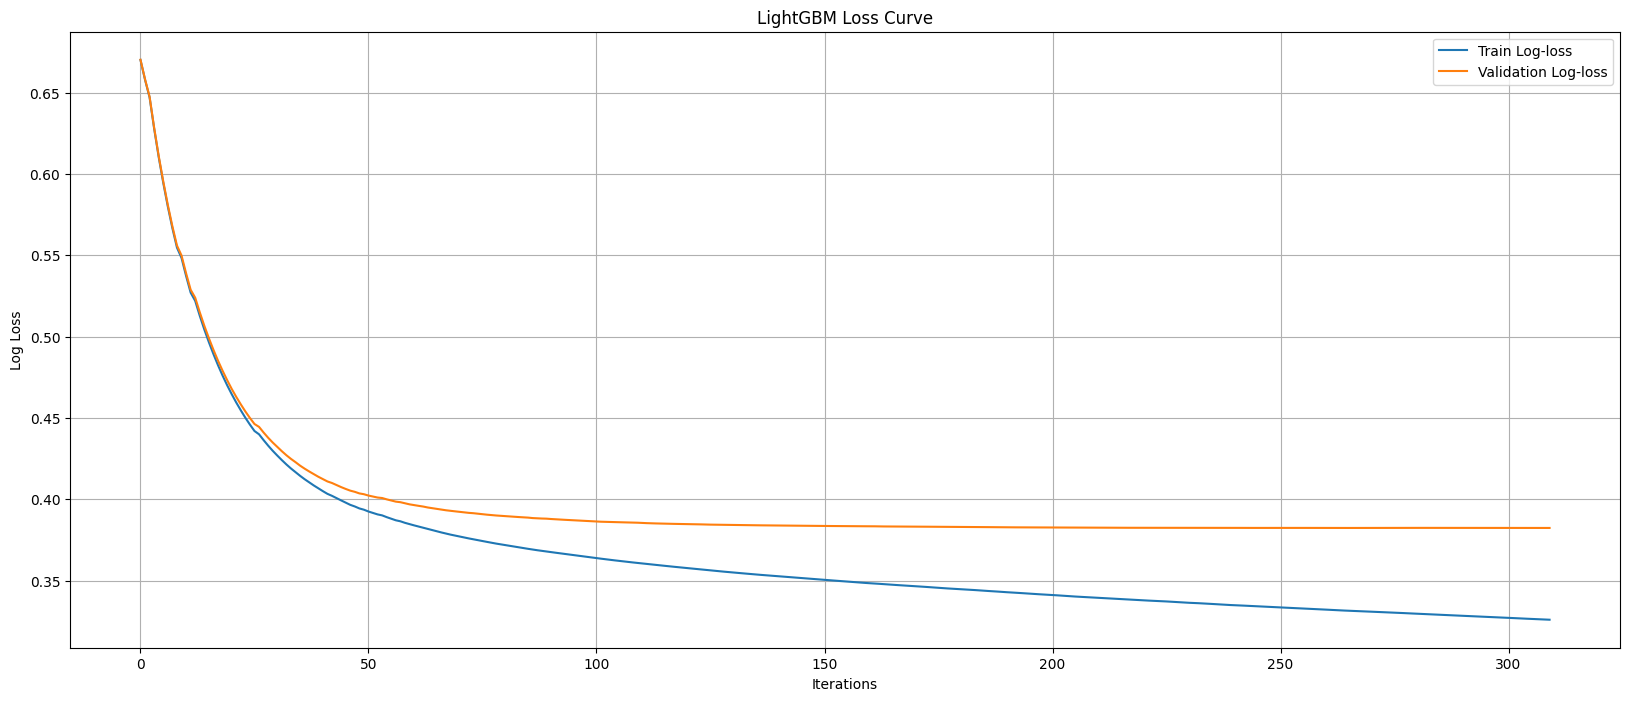

In [23]:
train_loss = evals_result["train"]["binary_logloss"]
valid_loss = evals_result["valid"]["binary_logloss"]

plt.figure(figsize=(20, 8))
plt.plot(train_loss, label="Train Log-loss")
plt.plot(valid_loss, label="Validation Log-loss")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("LightGBM Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


## Feature Importance

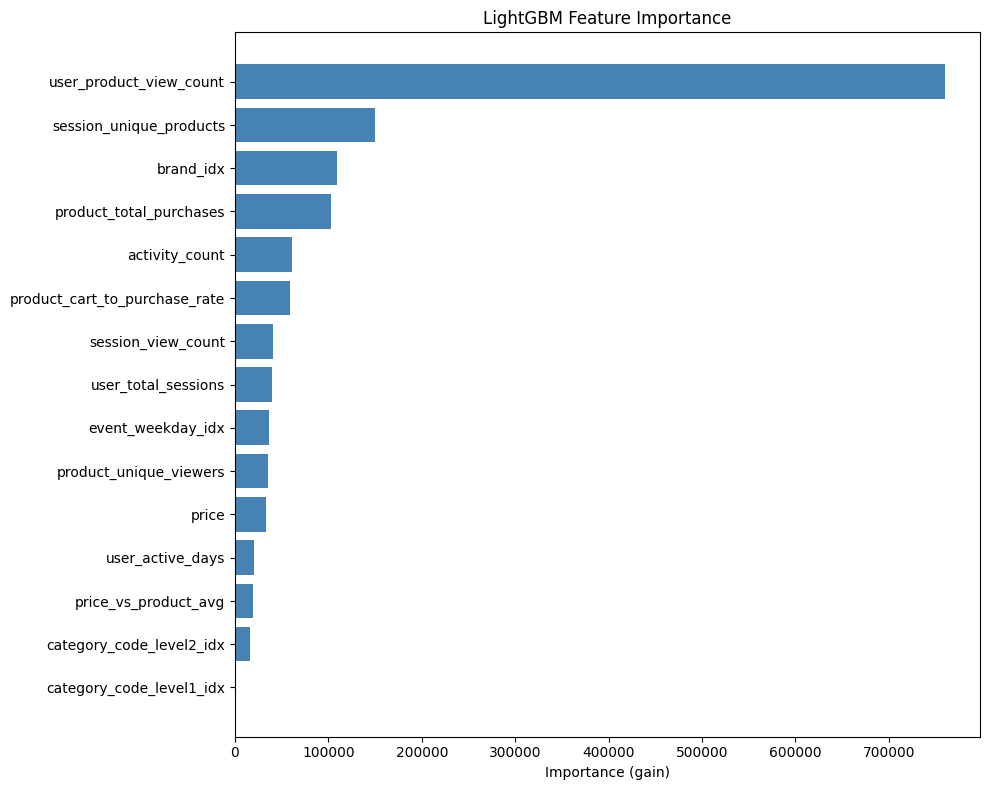

,feature,importance
0,user_product_view_count,759715.208825
1,session_unique_products,150171.562361
2,brand_idx,108756.525533
3,product_total_purchases,102531.943609
4,activity_count,61405.647968
5,product_cart_to_purchase_rate,58792.013616
6,session_view_count,40848.010222
7,user_total_sessions,39317.804929
8,event_weekday_idx,36345.456539
9,product_unique_viewers,35299.002475


In [24]:
importance_gain = lgb_model.feature_importance(importance_type="gain")

fi_df = (
    pd.DataFrame({"feature": ALL_FEATURE_COLS, "importance": importance_gain})
    .sort_values("importance", ascending=True)
)

plt.rcParams["figure.figsize"] = (10, 8)
plt.barh(fi_df["feature"], fi_df["importance"], color="steelblue")
plt.xlabel("Importance (gain)")
plt.title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()

fi_df[::-1].reset_index(drop=True)

## Kết thúc – Dừng Spark

In [25]:
spark.stop()
print("🎉 XONG! Tất cả kết quả đã được lưu trong:", OUTPUT_DIR)

🎉 XONG! Tất cả kết quả đã được lưu trong: /kaggle/working/models/lgbm_output
